<a href="https://colab.research.google.com/github/rsyadipras/PCVK_Ganjil2026/blob/main/Week7_21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **RISKY ADI PRASETYA - 244107020153 - TI3E/21**

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Library yang digunakan
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
from collections import deque
from scipy import ndimage as ndi
from skimage import data, filters, color, segmentation, feature, morphology
from skimage.filters import gaussian
from skimage.segmentation import flood

---
# Tugas 3 - Global Threshold manual (T = 200)
Lima jenis threshold ditulis dengan operasi NumPy, tanpa `cv.threshold()`.

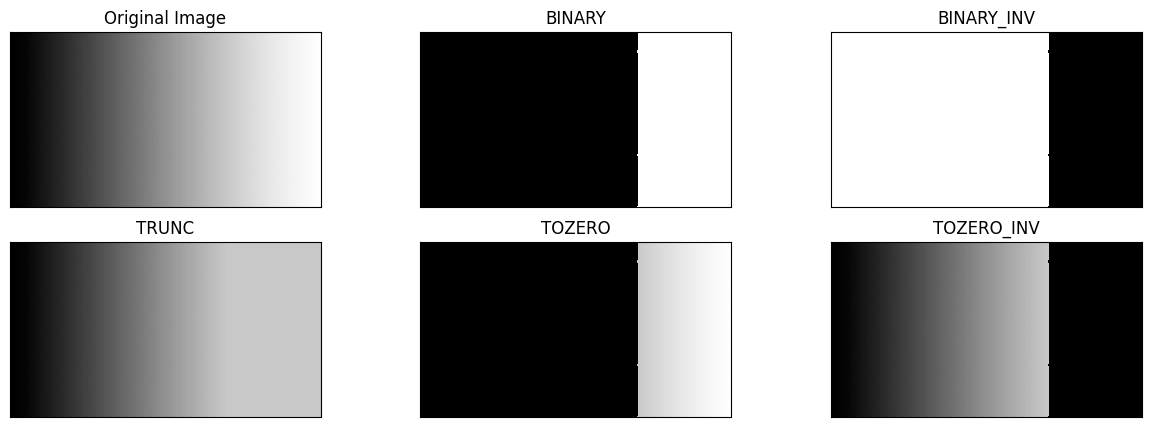

In [11]:
filename = ('/content/drive/MyDrive/PCVK2026/Images/gradient.jpg')
img = cv.imread(filename, cv.IMREAD_GRAYSCALE)
def global_manual(img, thresh, maxval, jenis):
    src = img.astype(np.int32)
    lebih = src > thresh                      # True bila piksel > thresh
    if jenis == 'BINARY':
        out = np.where(lebih, maxval, 0)
    elif jenis == 'BINARY_INV':
        out = np.where(lebih, 0, maxval)
    elif jenis == 'TRUNC':
        out = np.where(lebih, thresh, src)
    elif jenis == 'TOZERO':
        out = np.where(lebih, src, 0)
    elif jenis == 'TOZERO_INV':
        out = np.where(lebih, 0, src)
    return out.astype(np.uint8)


if img is None:
    img = np.tile(np.linspace(0, 255, 400).astype(np.uint8), (150, 1))

thresh, maxval = 200, 255
jenis_list = ['BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
hasil = [img] + [global_manual(img, thresh, maxval, j) for j in jenis_list]
judul = ['Original Image'] + jenis_list

plt.figure(figsize=(15, 5))
for i, (im_, t) in enumerate(zip(hasil, judul)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(im_, cmap='gray', vmin=0, vmax=255, interpolation='nearest')   # vmin/vmax agar tidak diskalakan ulang
    plt.title(t)
    plt.xticks([])
    plt.yticks([])

plt.show()

---
# Tugas 4 - Adaptive Threshold manual (mean & Gaussian)
Ketentuan: global threshold manual T = 127, jendela 11 × 11, C = 2, sigma = 2.
Ambang lokal `T(x,y) = rata-rata jendela − C`; piksel menjadi putih bila `I(x,y) > T(x,y)`. Rata-rata jendela dihitung dengan menjumlahkan salinan citra yang digeser (tanpa `cv.adaptiveThreshold`, tanpa fungsi filter siap pakai).

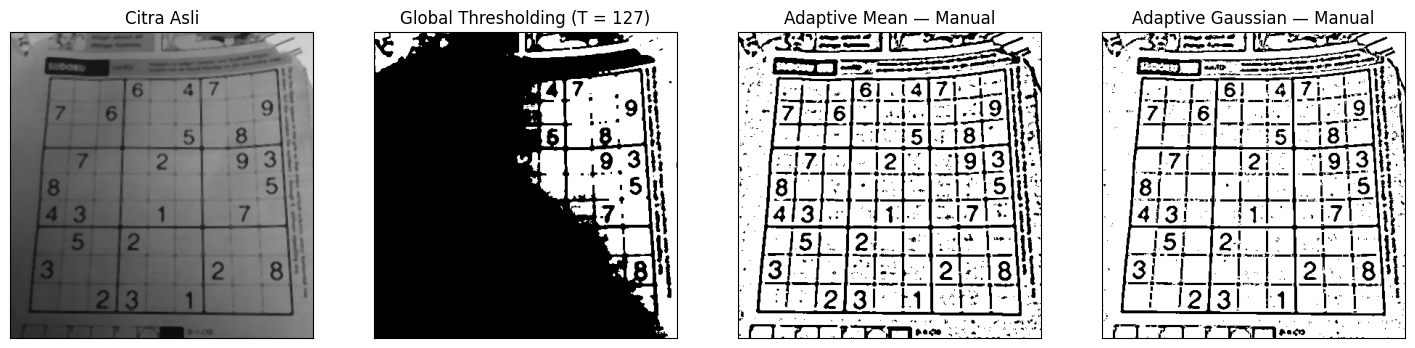

In [12]:
def kernel_gauss(b, sigma):
    r = b // 2
    ax = np.arange(-r, r + 1)
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    return k / k.sum()                         # bobot dinormalisasi, jumlah = 1


def lokal_rata(gray, b, bobot=None):
    r = b // 2
    pad = np.pad(gray.astype(np.float64), r, mode='edge')   # pinggir diperluas dengan piksel tepi
    H, W = gray.shape
    hasil = np.zeros((H, W))
    for dy in range(b):
        for dx in range(b):
            w = 1.0 / (b * b) if bobot is None else bobot[dy, dx]
            hasil += w * pad[dy:dy + H, dx:dx + W]
    return hasil


def adaptive_manual(gray, b=11, C=2, metode='mean', sigma=2):
    bobot = kernel_gauss(b, sigma) if metode == 'gaussian' else None
    T = np.round(lokal_rata(gray, b, bobot)) - C
    return np.where(gray > T, 255, 0).astype(np.uint8)


def global_127(gray, T=127):
    return np.where(gray > T, 255, 0).astype(np.uint8)

filename = ('/content/drive/MyDrive/PCVK2026/Images/sudoku-original.jpg')
citra = cv.medianBlur(cv.imread(filename),5)
gray = cv.cvtColor(citra, cv.COLOR_BGR2GRAY)

g_global = global_127(gray, 127)
g_mean   = adaptive_manual(gray, 11, 2, 'mean')
g_gauss  = adaptive_manual(gray, 11, 2, 'gaussian', sigma=2)

titles = ['Citra Asli', 'Global Thresholding (T = 127)', 'Adaptive Mean — Manual', 'Adaptive Gaussian — Manual']

plt.figure(figsize=(18, 5))
for i, (im_, t) in enumerate(zip([gray, g_global, g_mean, g_gauss], titles)):
    plt.subplot(1, 4, i + 1)
    plt.imshow(im_, cmap='gray', vmin=0, vmax=255)
    plt.title(t)
    plt.xticks([])
    plt.yticks([])

plt.show()